<a href="https://colab.research.google.com/github/dashatenoff/singl-layer-perceptron/blob/main/Singl%D1%83_layer_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Однослойный перцептрон: реализация, обучение и анализ

#Импорты

In [2]:
import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn import metrics

import matplotlib.pyplot as plt

#1. Подготовка данных

In [3]:
def generate_data():

    X, y = make_classification(
        n_samples=500,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        random_state=42,
        n_clusters_per_class=1
    )

    return X, y

In [36]:
def normalize_data(
    X_train,
    X_val=None,
    X_test=None
):

    mu = X_train.mean(axis=0)

    sigma = X_train.std(axis=0)

    X_train = (
        X_train - mu
    ) / sigma

    if X_val is not None:

        X_val = (
            X_val - mu
        ) / sigma

    if X_test is not None:

        X_test = (
            X_test - mu
        ) / sigma

    return X_train, X_val, X_test

In [5]:
def prepare_data(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.15,
        random_state=42,
        stratify=y_train
    )

    X_train, X_val, X_test = normalize_data(
        X_train,
        X_val,
        X_test
    )

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )

#2. Реализация перцептрона

In [7]:
class Perceptron:
    def __init__(self, input_dim, init_type="small_random"):
        if init_type == "zeros":
            self.w = np.zeros(input_dim)
        elif init_type == "large_random":
            self.w = np.random.randn(input_dim) * 10
        else:
            self.w = np.random.randn(input_dim) * 0.01

        self.b = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        z = X @ self.w + self.b
        y_pred = self.sigmoid(z)
        return y_pred

    def compute_loss(self, y_true, y_pred):
        eps = 1e-15
        L = - (y_true * np.log(y_pred+eps) + (1 - y_true)*(np.log(1-y_pred+eps)))
        return np.mean(L)

    def fit(self, X_train, y_train, X_val, y_val, epochs=100, lr=0.1, batch_size=32):
        train_loss = []
        test_loss = []

        for i in range(epochs):
            ind = np.random.permutation(X_train.shape[0])

            X_train = X_train[ind]
            y_train = y_train[ind]

            for st  in range(0, X_train.shape[0], batch_size):
                end = st + batch_size

                X_batch = X_train[st:end]
                y_batch = y_train[st:end]

                y_pred = self.forward(X_batch)

                self.w = self.w - lr * (X_batch.T @ (y_pred - y_batch) / X_batch.shape[0])
                self.b = self.b - lr * np.mean(y_pred - y_batch)

            y_pred_train = self.forward(X_train)
            y_pred_val = self.forward(X_val)

            train_loss.append( self.compute_loss(y_train, y_pred_train))
            test_loss.append(self.compute_loss(y_val, y_pred_val))

        return train_loss, test_loss

    def predict(self, X):
        y_pred = self.forward(X)
        return (y_pred >= 0.5).astype(int)

#3. Обучение и визуализация

In [9]:
X, y = generate_data()
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(X, y)

model = Perceptron(2)

train_loss, test_loss = model.fit(X_train, y_train, X_val, y_val, 100, 0.1, 32)

pred = model.predict(X_test)
acc = metrics.accuracy_score(y_test, pred)

pred_train = model.predict(X_train)
train_acc = metrics.accuracy_score(y_train, pred_train)

print(train_acc)
print(acc)

0.8720538720538721
0.8866666666666667


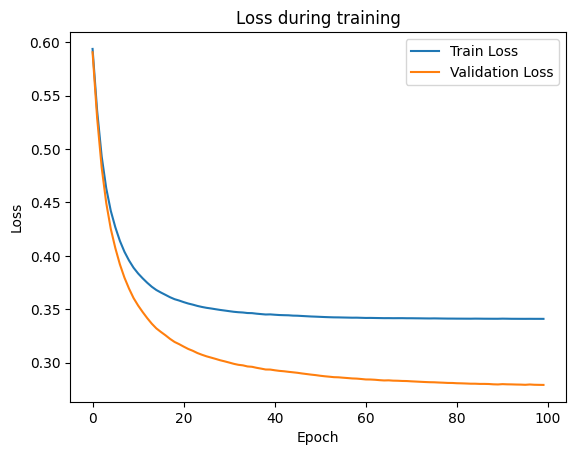

In [10]:
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()
plt.show()

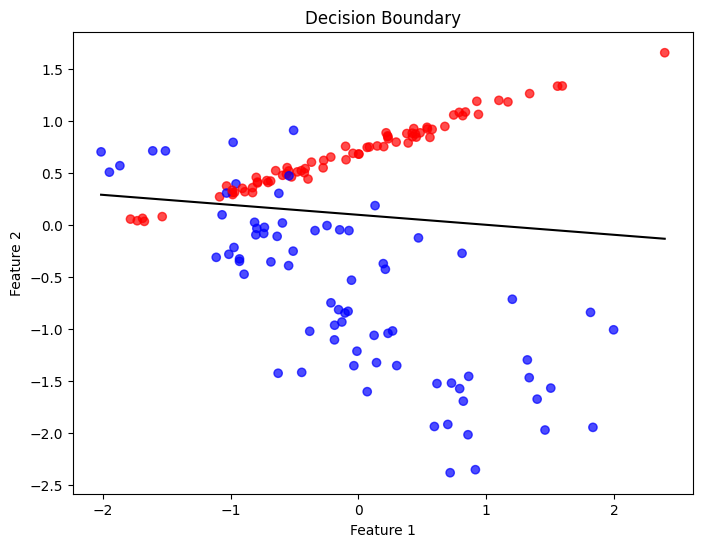

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap='bwr',
    alpha=0.7
)
x_min = X_test[:, 0].min()
x_max = X_test[:, 0].max()
x_line = np.linspace(x_min, x_max, 100)
w1 = model.w[0]
w2 = model.w[1]
b = model.b
y_line = -(w1 * x_line + b) / w2

plt.plot(x_line, y_line, color='black')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary')
plt.show()

#4. Эксперименты и анализ

In [10]:
def train_and_evaluate(lr=0.1, batch_size=32, ep = 100, init_type="small_random"):
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_data()

    model = Perceptron(
        2,
        init_type=init_type
    )

    train_loss, val_loss = model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=ep,
        lr=lr,
        batch_size=batch_size
    )

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = metrics.accuracy_score(
        y_train,
        pred_train
    )

    test_acc = metrics.accuracy_score(
        y_test,
        pred_test
    )

    return train_loss, val_loss, train_acc, test_acc

lr=0.001 | train_acc=0.862 | test_acc=0.880
lr=0.01 | train_acc=0.865 | test_acc=0.887
lr=0.1 | train_acc=0.872 | test_acc=0.887
lr=0.5 | train_acc=0.865 | test_acc=0.887
lr=1.0 | train_acc=0.862 | test_acc=0.887


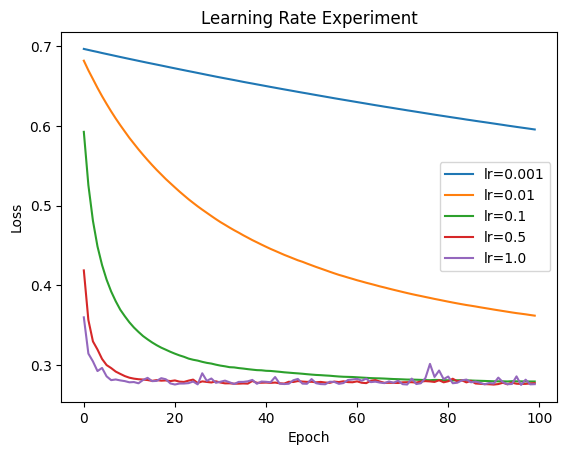

In [14]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]

batch_size = 32

for lr in learning_rates:

    train_loss, val_loss, train_acc, test_acc = (
        train_and_evaluate(
            lr=lr,
            batch_size=32
        )
    )

    plt.plot(
        val_loss,
        label=f"lr={lr}"
    )

    print(
        f"lr={lr} | "
        f"train_acc={train_acc:.3f} | "
        f"test_acc={test_acc:.3f}"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Experiment")
plt.legend()
plt.show()

batch_size=1 | train_acc=0.869 | test_acc=0.887
batch_size=16 | train_acc=0.872 | test_acc=0.887
batch_size=32 | train_acc=0.872 | test_acc=0.887
batch_size=64 | train_acc=0.869 | test_acc=0.887
batch_size=256 | train_acc=0.865 | test_acc=0.887


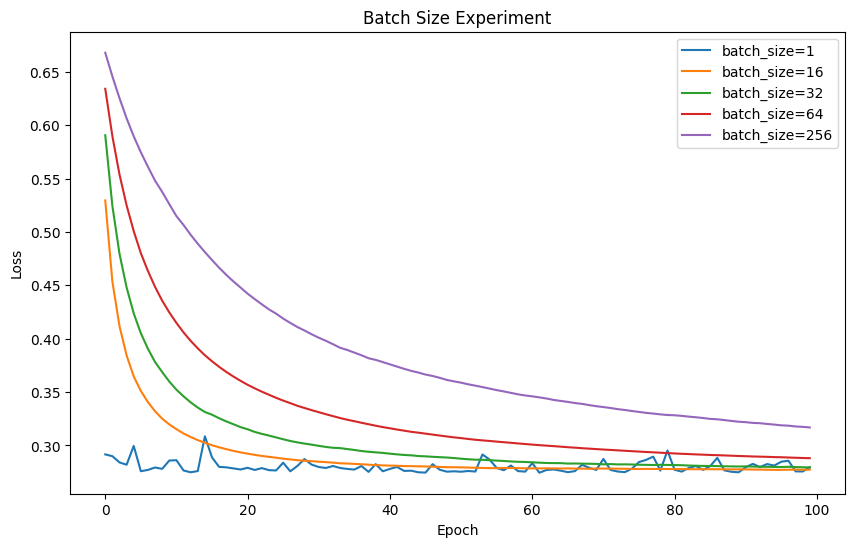

In [16]:
batch_sizes = [1, 16, 32, 64, 256]
lr = 0.1

plt.figure(figsize=(10, 6))

for bs in batch_sizes:

    train_loss, val_loss, train_acc, test_acc = (
        train_and_evaluate(
            lr=0.1,
            batch_size=bs
        )
    )

    plt.plot(
        val_loss,
        label=f"batch_size={bs}"
    )

    print(
        f"batch_size={bs} | "
        f"train_acc={train_acc:.3f} | "
        f"test_acc={test_acc:.3f}"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Batch Size Experiment")
plt.legend()
plt.show()

zeros | train_acc=0.865 | test_acc=0.887
small_random | train_acc=0.862 | test_acc=0.887
large_random | train_acc=0.865 | test_acc=0.887


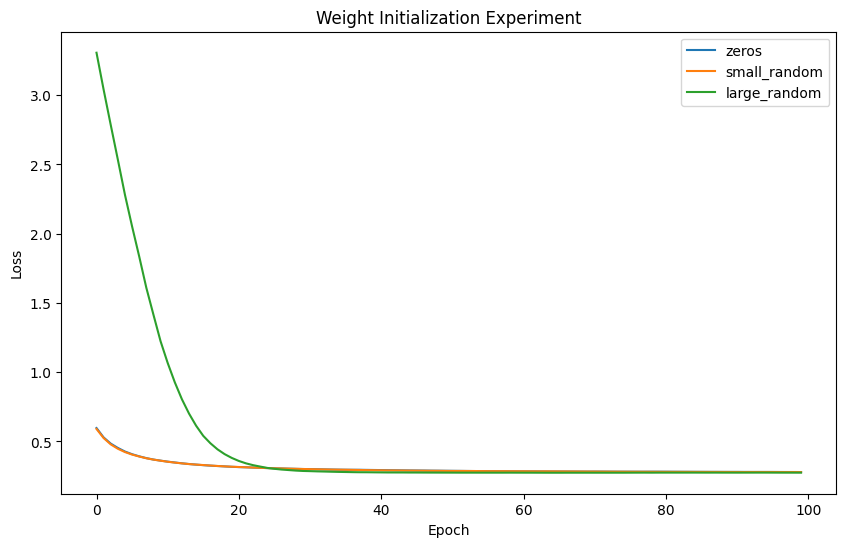

In [17]:
init_types = [
    "zeros",
    "small_random",
    "large_random"
]

plt.figure(figsize=(10, 6))

for init_type in init_types:

    train_loss, val_loss, train_acc, test_acc = (
        train_and_evaluate(
            init_type=init_type
        )
    )

    plt.plot(
        val_loss,
        label=init_type
    )

    print(
        f"{init_type} | "
        f"train_acc={train_acc:.3f} | "
        f"test_acc={test_acc:.3f}"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Weight Initialization Experiment")
plt.legend()
plt.show()

#Собственный генератор данных

In [18]:
def generate_linear_data(n_samples=500, noise=0.0):
    n_noise = int(noise*n_samples)
    noise_idx = np.random.choice(n_samples, n_noise, replace=False)
    mean0 = np.array([-2, -2])
    mean1 = np.array([2, 2])

    cov = np.array([
        [1, 0],
        [0, 1]
    ])

    X0 = np.random.multivariate_normal(
        mean0,
        cov,
        n_samples // 2
    )

    X1 = np.random.multivariate_normal(
        mean1,
        cov,
        n_samples // 2
    )

    y0 = np.zeros(n_samples // 2)
    y1 = np.ones(n_samples // 2)

    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])
    y[noise_idx] = 1-y[noise_idx]

    return X, y

In [22]:
def generate_circle_data(n_samples=500, radius=2, noise=0.0):
    n_noise = int(noise*n_samples)
    noise_idx = np.random.choice(n_samples, n_noise, replace=False)

    X = np.random.uniform(-4, 4, (n_samples, 2))
    y = (X[:, 0]**2 + X[:, 1]**2 > radius**2).astype(int)
    y[noise_idx] = 1-y[noise_idx]
    return X, y

In [52]:
X_lin, y_lin = generate_linear_data()
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(X_lin, y_lin)

model_lin = Perceptron(2)
train_loss, test_loss = model_lin.fit(X_train, y_train, X_val, y_val)

pred = model_lin.predict(X_test)
acc = metrics.accuracy_score(y_test, pred)

pred_train = model_lin.predict(X_train)
train_acc = metrics.accuracy_score(y_train, pred_train)

print(train_acc)
print(acc)

1.0
1.0


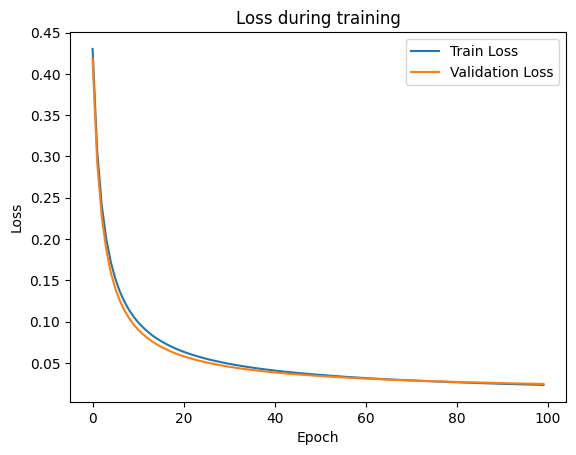

In [53]:
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()
plt.show()



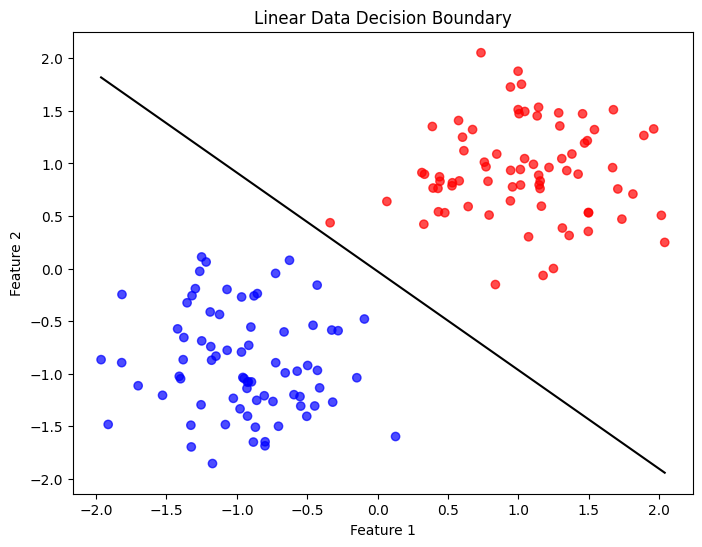

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap='bwr',
    alpha=0.7
)
x_min = X_test[:, 0].min()
x_max = X_test[:, 0].max()
x_line = np.linspace(x_min, x_max, 100)
w1 = model_lin.w[0]
w2 = model_lin.w[1]
b = model_lin.b
y_line = -(w1 * x_line + b) / w2

plt.plot(x_line, y_line, color='black')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear Data Decision Boundary')
plt.show()

In [55]:
X_cir, y_cir = generate_circle_data()
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(X_cir, y_cir)

model_cir = Perceptron(2)
train_loss, test_loss = model_cir.fit(X_train, y_train, X_val, y_val)

pred = model_cir.predict(X_test)
acc = metrics.accuracy_score(y_test, pred)

pred_train = model_cir.predict(X_train)
train_acc = metrics.accuracy_score(y_train, pred_train)

print(train_acc)
print(acc)

0.8013468013468014
0.8066666666666666


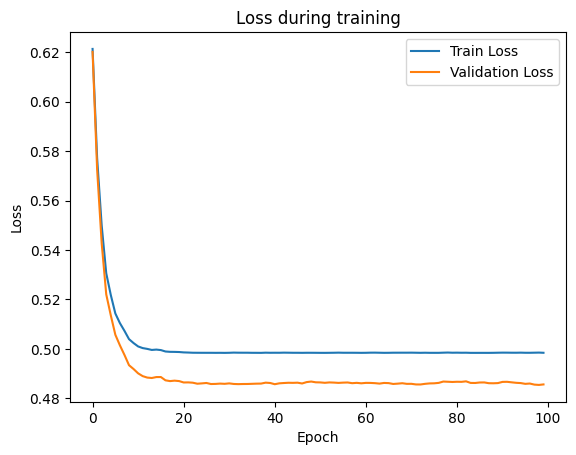

In [56]:
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()
plt.show()



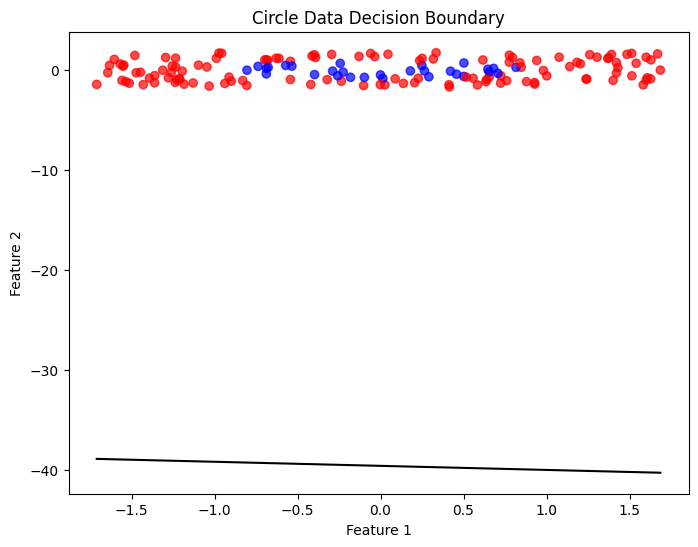

In [57]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap='bwr',
    alpha=0.7
)
x_min = X_test[:, 0].min()
x_max = X_test[:, 0].max()
x_line = np.linspace(x_min, x_max, 100)
w1 = model_cir.w[0]
w2 = model_cir.w[1]
b = model_cir.b
y_line = -(w1 * x_line + b) / w2

plt.plot(x_line, y_line, color='black')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Circle Data Decision Boundary')
plt.show()

На линейно разделимых данных перцептрон показал высокое качество классификации (accuracy = 1.0) и смог построить корректную разделяющую границу между классами. Функция потерь быстро уменьшалась в процессе обучения, что говорит о хорошей сходимости модели.

На данных типа «окружность» качество классификации значительно ухудшилось (accuracy ≈ 0.81), так как классы не являются линейно разделимыми. Однослойный перцептрон строит только линейную границу и поэтому не способен корректно разделять нелинейные структуры данных.

#Дополнительные функции потерь и регуляризация

##Функцию потерь Hinge loss

In [59]:
class HingePerceptron:
    def __init__(self, input_dim, init_type="small_random"):
        if init_type == "zeros":
            self.w = np.zeros(input_dim)
        elif init_type == "large_random":
            self.w = np.random.randn(input_dim) * 10
        else:
            self.w = np.random.randn(input_dim) * 0.01

        self.b = 0

    def forward(self, X):
        z = X @ self.w + self.b
        return  z

    def compute_loss(self, y_true, z):
        L = np.maximum(0, 1 - y_true*z)
        return np.mean(L)

    def fit(self, X_train, y_train, X_val, y_val, epochs=100, lr=0.1, batch_size=32):
        train_loss = []
        test_loss = []

        y_train = np.where(y_train == 0, -1, 1)
        y_val = np.where(y_val == 0, -1, 1)

        for i in range(epochs):
            ind = np.random.permutation(X_train.shape[0])

            X_train = X_train[ind]
            y_train = y_train[ind]

            for st  in range(0, X_train.shape[0], batch_size):
                end = st + batch_size

                X_batch = X_train[st:end]
                y_batch = y_train[st:end]

                z = self.forward(X_batch)

                margin = y_batch*z
                mask = margin<1

                if np.sum(mask) > 0:

                    dw = -(
                        X_batch[mask].T @ y_batch[mask]
                    ) / X_batch.shape[0]

                    db = -np.mean(
                        y_batch[mask]
                    )

                    self.w -= lr * dw
                    self.b -= lr * db

            y_pred_train = self.forward(X_train)
            y_pred_val = self.forward(X_val)

            train_loss.append( self.compute_loss(y_train, y_pred_train))
            test_loss.append(self.compute_loss(y_val, y_pred_val))

        return train_loss, test_loss

    def predict(self, X):
        y_pred = self.forward(X)
        return (y_pred >= 0).astype(int)

BCE accuracy: 0.887
Hinge accuracy: 0.920


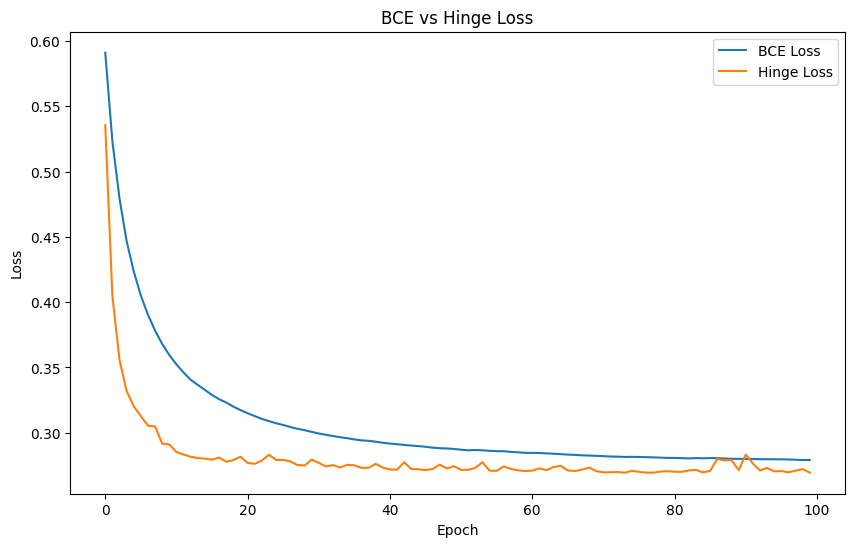

In [60]:
X, y = generate_data()
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(X, y)



model_bce = Perceptron(2)

train_loss_bce, val_loss_bce = model_bce.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=100,
    lr=0.1,
    batch_size=32
)



model_hinge = HingePerceptron(2)

train_loss_hinge, val_loss_hinge = model_hinge.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=100,
    lr=0.1,
    batch_size=32
)



pred_bce = model_bce.predict(X_test)
pred_hinge = model_hinge.predict(X_test)



acc_bce = metrics.accuracy_score(
    y_test,
    pred_bce
)

acc_hinge = metrics.accuracy_score(
    y_test,
    pred_hinge
)


print(f"BCE accuracy: {acc_bce:.3f}")
print(f"Hinge accuracy: {acc_hinge:.3f}")



plt.figure(figsize=(10, 6))

plt.plot(
    val_loss_bce,
    label="BCE Loss"
)

plt.plot(
    val_loss_hinge,
    label="Hinge Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("BCE vs Hinge Loss")

plt.legend()

plt.show()

##L2-регуляризацию

In [61]:
import numpy as np


class RegularizedPerceptron:

    def __init__(
        self,
        input_dim,
        init_type="small_random",
        l2_lambda=0.0
    ):

        self.l2_lambda = l2_lambda

        if init_type == "zeros":

            self.w = np.zeros(input_dim)

        elif init_type == "large_random":

            self.w = np.random.randn(input_dim) * 10

        else:

            self.w = np.random.randn(input_dim) * 0.01

        self.b = 0


    def sigmoid(self, z):

        return 1 / (1 + np.exp(-z))


    def forward(self, X):

        z = X @ self.w + self.b

        y_pred = self.sigmoid(z)

        return y_pred


    def compute_loss(self, y_true, y_pred):

        eps = 1e-15

        bce = -(
            y_true * np.log(y_pred + eps)
            + (1 - y_true)
            * np.log(1 - y_pred + eps)
        )

        bce = np.mean(bce)
        l2 = self.l2_lambda * np.sum(
            self.w ** 2
        )
        return bce + l2 #add l2


    def fit(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=100,
        lr=0.1,
        batch_size=32
    ):

        train_loss = []
        val_loss = []

        for i in range(epochs):

            ind = np.random.permutation(
                X_train.shape[0]
            )

            X_train = X_train[ind]
            y_train = y_train[ind]

            for st in range(
                0,
                X_train.shape[0],
                batch_size
            ):

                end = st + batch_size

                X_batch = X_train[st:end]
                y_batch = y_train[st:end]

                y_pred = self.forward(X_batch)

                dw = (
                    X_batch.T @ (
                        y_pred - y_batch
                    )
                ) / X_batch.shape[0]

                # L2 regularization gradient
                dw += (
                    2
                    * self.l2_lambda
                    * self.w
                )

                db = np.mean(
                    y_pred - y_batch
                )

                self.w -= lr * dw
                self.b -= lr * db

            y_pred_train = self.forward(
                X_train
            )

            y_pred_val = self.forward(
                X_val
            )

            train_loss.append(
                self.compute_loss(
                    y_train,
                    y_pred_train
                )
            )

            val_loss.append(
                self.compute_loss(
                    y_val,
                    y_pred_val
                )
            )

        return train_loss, val_loss


    def predict(self, X):

        y_pred = self.forward(X)

        return (y_pred >= 0.5).astype(int)

lambda=0.0 | train_acc=0.872 | test_acc=0.887 | ||w||=3.022
lambda=0.001 | train_acc=0.865 | test_acc=0.887 | ||w||=2.878
lambda=0.01 | train_acc=0.869 | test_acc=0.887 | ||w||=2.088
lambda=0.1 | train_acc=0.862 | test_acc=0.887 | ||w||=0.856
lambda=1.0 | train_acc=0.865 | test_acc=0.887 | ||w||=0.161


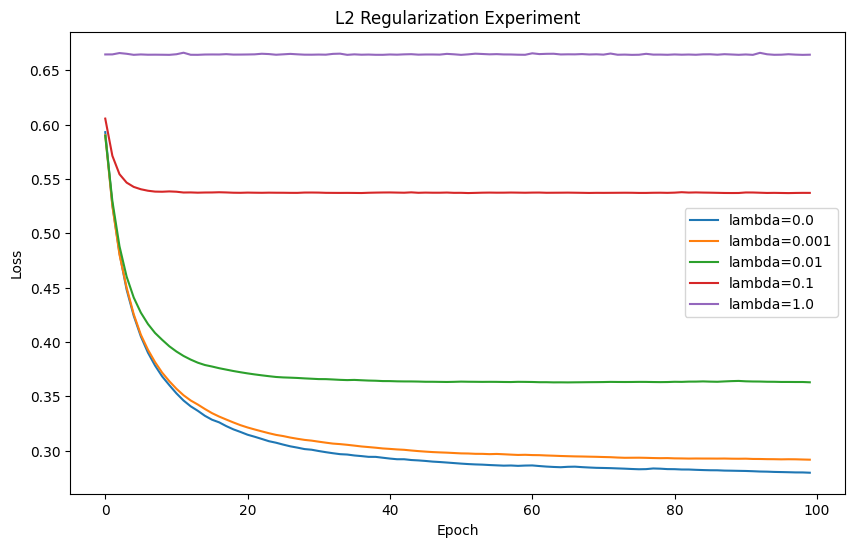

In [63]:
lambdas = [
    0.0,
    0.001,
    0.01,
    0.1,
    1.0
]


plt.figure(figsize=(10, 6))

results = []


for lam in lambdas:

    model = RegularizedPerceptron(
        2,
        l2_lambda=lam
    )

    train_loss, val_loss = model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=100,
        lr=0.1,
        batch_size=32
    )

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = metrics.accuracy_score(
        y_train,
        pred_train
    )

    test_acc = metrics.accuracy_score(
        y_test,
        pred_test
    )

    weight_norm = np.linalg.norm(
        model.w
    )

    results.append([
        lam,
        train_acc,
        test_acc,
        weight_norm
    ])

    print(
        f"lambda={lam} | "
        f"train_acc={train_acc:.3f} | "
        f"test_acc={test_acc:.3f} | "
        f"||w||={weight_norm:.3f}"
    )

    plt.plot(
        val_loss,
        label=f"lambda={lam}"
    )


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("L2 Regularization Experiment")

plt.legend()

plt.show()


При небольших значениях λ (0.001–0.01) качество модели практически не ухудшается, а обучение остаётся стабильным.

При больших значениях λ (0.1 и особенно 1.0) регуляризация слишком сильно штрафует веса модели, из-за чего перцептрон не может эффективно обучаться.

#Метрики качества и анализ ошибок

In [12]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [16]:
precision = precision_score(y_test, pred)

recall = recall_score(y_test, pred)

f1 = f1_score(y_test, pred)

In [14]:
y_prob = model.forward(X_test)

roc_auc = roc_auc_score( y_test, y_prob)

In [17]:
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

Precision: 0.854
Recall: 0.933
F1-score: 0.892
ROC-AUC: 0.941


In [19]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

[           inf 9.95589396e-01 9.12349443e-01 9.09999832e-01
 8.77247506e-01 8.61274591e-01 8.06540108e-01 8.01471064e-01
 7.83834368e-01 7.77109932e-01 7.26985537e-01 7.26924298e-01
 7.16755950e-01 7.08574228e-01 6.67996836e-01 6.50739088e-01
 6.24195391e-01 6.09143205e-01 5.88897099e-01 5.75977343e-01
 5.52179189e-01 3.82181664e-01 3.77814775e-01 3.59345861e-01
 3.55922526e-01 3.48287770e-01 3.36664028e-01 6.72236843e-04]


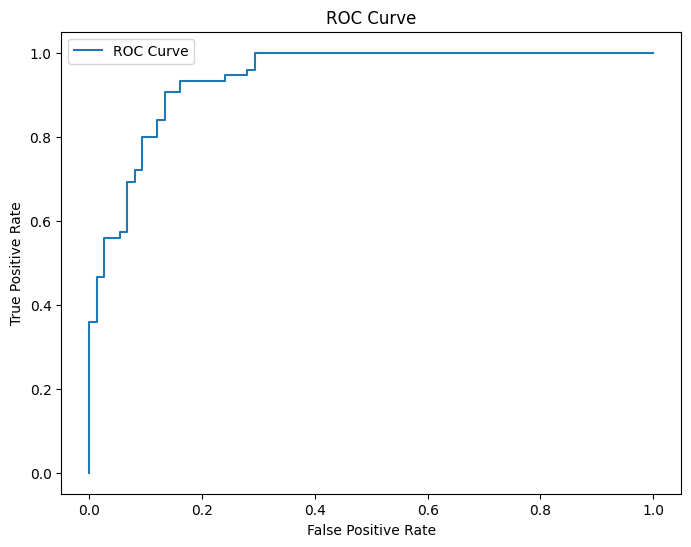

In [20]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="ROC Curve"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

#Исследование сходимости градиентного спуска

In [23]:
class MomentumPerceptron:
    def __init__(self, input_dim, init_type="small_random", beta=0):
        if init_type == "zeros":
            self.w = np.zeros(input_dim)
        elif init_type == "large_random":
            self.w = np.random.randn(input_dim) * 10
        else:
            self.w = np.random.randn(input_dim) * 0.01

        self.b = 0
        self.vw = np.zeros(input_dim)
        self.vb = 0
        self.beta = beta

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        z = X @ self.w + self.b
        y_pred = self.sigmoid(z)
        return y_pred

    def compute_loss(self, y_true, y_pred):
        eps = 1e-15
        L = - (y_true * np.log(y_pred+eps) + (1 - y_true)*(np.log(1-y_pred+eps)))
        return np.mean(L)

    def fit(self, X_train, y_train, X_val, y_val, epochs=100, lr=0.1, batch_size=32):
        train_loss = []
        test_loss = []

        for i in range(epochs):
            ind = np.random.permutation(X_train.shape[0])

            X_train = X_train[ind]
            y_train = y_train[ind]

            for st  in range(0, X_train.shape[0], batch_size):
                end = st + batch_size

                X_batch = X_train[st:end]
                y_batch = y_train[st:end]

                y_pred = self.forward(X_batch)

                dw = (X_batch.T @ (y_pred - y_batch) / X_batch.shape[0])
                db = np.mean(y_pred - y_batch)

                self.vw = self.vw * self.beta + dw
                self.vb = self.vb * self.beta + db
                self.w = self.w - lr * self.vw
                self.b = self.b - lr * self.vb

            y_pred_train = self.forward(X_train)
            y_pred_val = self.forward(X_val)

            train_loss.append( self.compute_loss(y_train, y_pred_train))
            test_loss.append(self.compute_loss(y_val, y_pred_val))

        return train_loss, test_loss

    def predict(self, X):
        y_pred = self.forward(X)
        return (y_pred >= 0.5).astype(int)

beta=0 | accuracy=0.887
beta=0.5 | accuracy=0.887
beta=0.9 | accuracy=0.887
beta=0.99 | accuracy=0.880


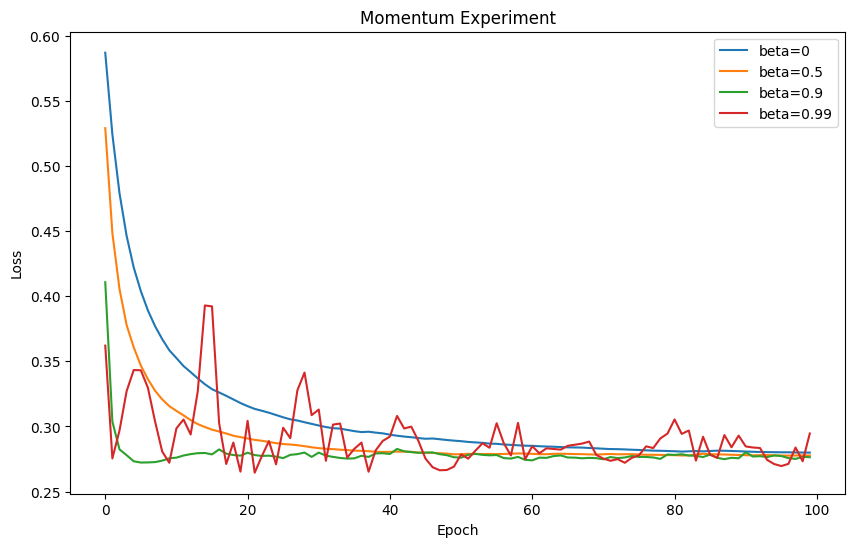

In [24]:
X, y = generate_data()

X_train, X_val, X_test, y_train, y_val, y_test = (
    prepare_data(X, y)
)


betas = [
    0,
    0.5,
    0.9,
    0.99
]


plt.figure(figsize=(10, 6))


for beta in betas:

    model = MomentumPerceptron(
        2,
        beta=beta
    )

    train_loss, val_loss = model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=100,
        lr=0.1,
        batch_size=32
    )

    pred = model.predict(X_test)

    acc = metrics.accuracy_score(
        y_test,
        pred
    )

    print(
        f"beta={beta} | "
        f"accuracy={acc:.3f}"
    )

    plt.plot(
        val_loss,
        label=f"beta={beta}"
    )


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Momentum Experiment")

plt.legend()

plt.show()

Добавление momentum ускорило сходимость градиентного спуска по сравнению с обычным SGD (β = 0). При значениях β = 0.5 и особенно β = 0.9 функция потерь уменьшалась быстрее и обучение проходило более плавно и стабильно.

#Кросс-валидация и подбор гиперпараметров

In [38]:
from sklearn.model_selection import KFold

X, y = generate_data()

learning_rates = [
    0.001,
    0.01,
    0.1
]

batch_sizes = [
    16,
    32,
    64
]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_acc = 0
best_params = None

for lr in learning_rates:
    for bs in batch_sizes:

      scores = []

      for train_idx, val_idx in kf.split(X):

        X_train = X[train_idx]
        X_val = X[val_idx]

        y_train = y[train_idx]
        y_val = y[val_idx]

        X_train, X_val, _ = normalize_data(
            X_train,
            X_val
        )


        model = Perceptron(2)

        model.fit(
            X_train,
            y_train,
            X_val,
            y_val,
            epochs=100,
            lr=lr,
            batch_size=bs
        )


        pred = model.predict(X_val)

        acc = metrics.accuracy_score(
            y_val,
            pred
        )

        scores.append(acc)
      mean_acc = np.mean(scores)
      std_acc = np.std(scores)

      print(
          f"lr={lr} | "
          f"batch_size={bs} | "
          f"mean_acc={mean_acc:.3f} | "
          f"std={std_acc:.3f}"
      )

      if mean_acc > best_acc:

        best_acc = mean_acc

        best_params = (lr, bs)


print()
print("Best parameters:")
print(best_params)
print(f"Best CV accuracy: {best_acc:.3f}")


lr=0.001 | batch_size=16 | mean_acc=0.862 | std=0.038
lr=0.001 | batch_size=32 | mean_acc=0.864 | std=0.039
lr=0.001 | batch_size=64 | mean_acc=0.864 | std=0.040
lr=0.01 | batch_size=16 | mean_acc=0.878 | std=0.026
lr=0.01 | batch_size=32 | mean_acc=0.874 | std=0.030
lr=0.01 | batch_size=64 | mean_acc=0.864 | std=0.035
lr=0.1 | batch_size=16 | mean_acc=0.880 | std=0.029
lr=0.1 | batch_size=32 | mean_acc=0.880 | std=0.029
lr=0.1 | batch_size=64 | mean_acc=0.878 | std=0.026

Best parameters:
(0.1, 16)
Best CV accuracy: 0.880


In [39]:
best_lr, best_bs = best_params

model = Perceptron(2)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=100,
    lr=best_lr,
    batch_size=best_bs
)

acc = metrics.accuracy_score(
    y_test,
    pred
)

print(f"Accuracy: {acc:.3f}")

([np.float64(0.5056281108690873),
  np.float64(0.4340016227749875),
  np.float64(0.39843050263757257),
  np.float64(0.377492352058125),
  np.float64(0.3639810688665336),
  np.float64(0.35490532073892944),
  np.float64(0.34825628151498095),
  np.float64(0.3433037212391683),
  np.float64(0.33952262149789386),
  np.float64(0.3365953933140054),
  np.float64(0.33418415862849943),
  np.float64(0.3322862045705118),
  np.float64(0.33074420192667225),
  np.float64(0.32945996564565405),
  np.float64(0.32839457859921695),
  np.float64(0.3274814786843914),
  np.float64(0.32671285184978116),
  np.float64(0.3260808248070082),
  np.float64(0.32554265559453444),
  np.float64(0.3250722127247292),
  np.float64(0.3246644405818834),
  np.float64(0.3242943806219337),
  np.float64(0.3239835570073237),
  np.float64(0.32371696747756057),
  np.float64(0.3234976455868395),
  np.float64(0.32328986477991495),
  np.float64(0.32311554793731756),
  np.float64(0.32295545563622646),
  np.float64(0.322831740095534),
  